In [1]:
import scipy as sp
from surprise import Dataset, Reader

In [2]:
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from tqdm import tqdm # Per la barra di progresso
import numpy as np
from surprise import model_selection, KNNBasic, SVD
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from surprise.model_selection import GridSearchCV, cross_validate
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

# Impostazione per evitare memory leak di KMeans su Windows, risolve un warning, lo trovato su internet
import os
os.environ['OMP_NUM_THREADS'] = '2'
OMP_NUM_THREADS=2

In [3]:
#leggo i csv di user reviews e item meta, utilizziamo musical istruments
rev = pd.read_csv("amazon_reviews_Musical_Instruments.csv", on_bad_lines='skip')
# amazon_reviews_Musical_Instruments.csv
item = pd.read_csv("amazon_meta_Musical_Instruments.csv", on_bad_lines='skip')
# amazon_meta_Musical_Instruments.csv

In [4]:
rev.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Five Stars,"Great headphones, comfortable and sound is goo...",[],B003LPTAYI,B003LPTAYI,AGKASBHYZPGTEPO6LWZPVJWB2BVA,1452650586000,0,True
1,3.0,nice sound. pedal failed after less than 1 year,I like the piano.. but the sustain pedal faile...,[],B00723436A,B06XP6TDVY,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,1558567365290,2,True
2,4.0,okay,pretty good overall. I like it. the controll...,[],B0040FJ27S,B0040FJ27S,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,1384912482000,0,True
3,3.0,Easy to return.,Too bad it didn't work. At least the return pr...,[],B00191WVF6,B00WJ3HL5I,AEM663T6XHZFWLODF4US2RCOCUSA,1607055693671,0,True
4,5.0,Good product despite tight bolt.,Good and sturdy but the bolt was hell to get o...,[],B07T9NM5QR,B07T9NM5QR,AFJTRBXMURLHS5EGNXLUHDHIZRFQ,1622595785255,0,False


In [5]:
# stampiamo le colonne del dataset "rev"
print(rev.columns)

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='object')


In [6]:
print(item.columns)

Index(['main_category', 'title', 'average_rating', 'rating_number', 'features',
       'description', 'price', 'images', 'videos', 'store', 'categories',
       'details', 'parent_asin', 'bought_together', 'subtitle', 'author'],
      dtype='object')


In [7]:
# ci prendiamo solo le colonne necessarie
df = rev[['user_id', 'parent_asin', 'rating']]  # user, item, rating
df = df.dropna()

# Rinomina
df.columns = ['userID', 'itemID', 'rating']
print(df.head())

                         userID      itemID  rating
0  AGKASBHYZPGTEPO6LWZPVJWB2BVA  B003LPTAYI     5.0
1  AGCI7FAH4GL5FI65HYLKWTMFZ2CQ  B06XP6TDVY     3.0
2  AGCI7FAH4GL5FI65HYLKWTMFZ2CQ  B0040FJ27S     4.0
3  AEM663T6XHZFWLODF4US2RCOCUSA  B00WJ3HL5I     3.0
4  AFJTRBXMURLHS5EGNXLUHDHIZRFQ  B07T9NM5QR     5.0


# Analisi esplorativa
statistiche descrittive, frequenze utenti e prodotti, distribuzione dei rating, heatmap di correlazione

In [8]:
df.isnull().sum()

userID    0
itemID    0
rating    0
dtype: int64

In [9]:
#1. stastiche descrittive
print("Numero utenti unici:", df['userID'].nunique())
print("Numero item unici:", df['itemID'].nunique())
print("Numero totale di recensioni:", len(df))
print(df['rating'].describe())

Numero utenti unici: 1762679
Numero item unici: 213571
Numero totale di recensioni: 3017439
count    3.017439e+06
mean     4.255534e+00
std      1.278107e+00
min      1.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


In [47]:
print(df['rating'].describe().round())

count    3017439.0
mean           4.0
std            1.0
min            1.0
25%            4.0
50%            5.0
75%            5.0
max            5.0
Name: rating, dtype: float64


Numero medio di recensioni per utente: 1.71
Mediana recensioni per utente: 1.0
Utente che ha fatto più recensioni: 497
Utente che ha fatto meno recensioni: 1
Numero totale di utenti: 1762679


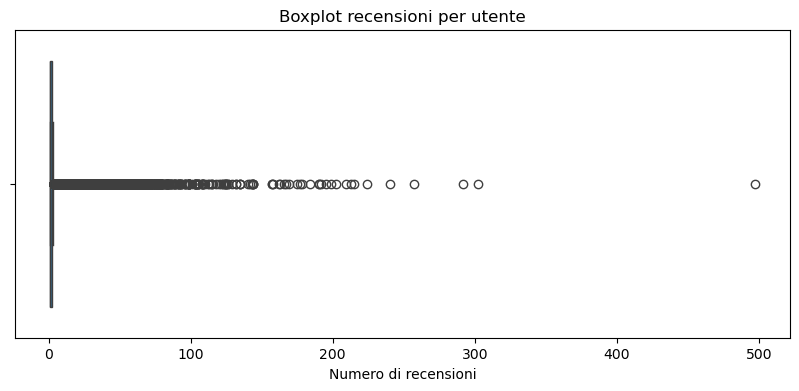

In [10]:
#statistiche utenti/review
user_review_counts = df['userID'].value_counts()
print("Numero medio di recensioni per utente:", user_review_counts.mean().round(2))
print("Mediana recensioni per utente:", user_review_counts.median())
print("Utente che ha fatto più recensioni:", user_review_counts.max())
print("Utente che ha fatto meno recensioni:", user_review_counts.min())
print("Numero totale di utenti:", user_review_counts.shape[0])
#visualizzo grafico boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=user_review_counts)
plt.title("Boxplot recensioni per utente")
plt.xlabel("Numero di recensioni")
plt.show()

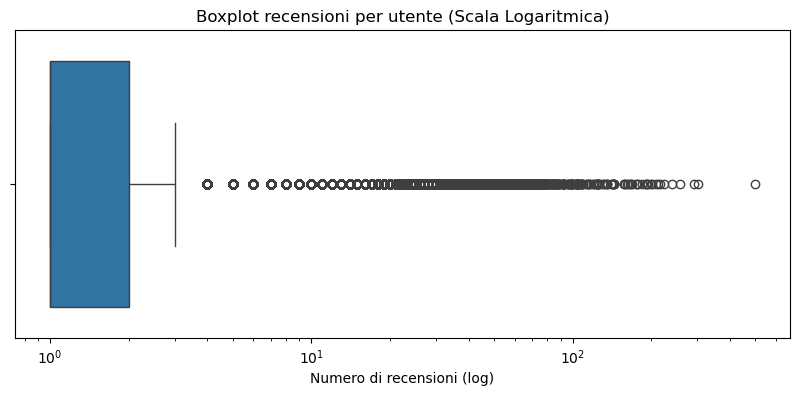

In [11]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=user_review_counts)
plt.xscale('log') # usaimo una scala logaritmica
plt.title("Boxplot recensioni per utente (Scala Logaritmica)")
plt.xlabel("Numero di recensioni (log)")
plt.show()

Numero medio di recensioni per item: 14.13
Mediana recensioni per item: 2.0
Item che ha ricevuto più recensioni: 9334
Item che ha ricevuto meno recensioni: 1
Numero totale di item: 213571


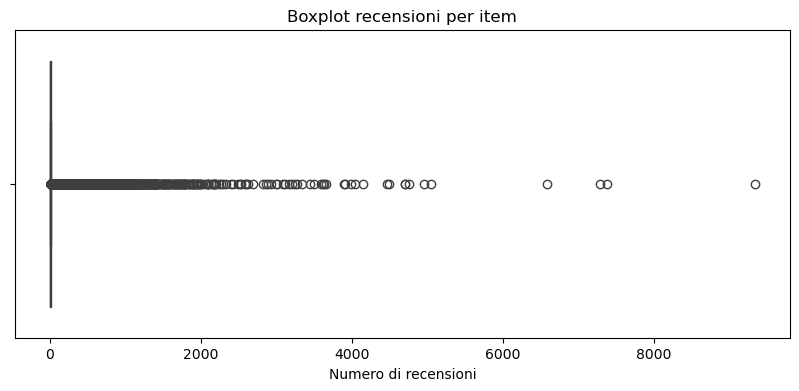

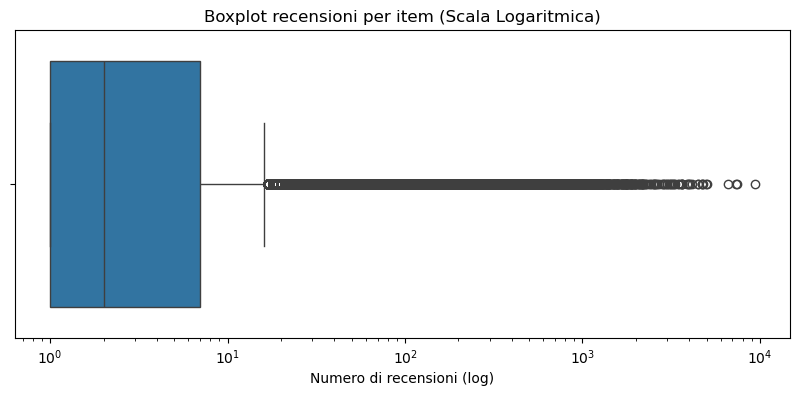

In [12]:
# statistiche item/review
item_review_counts = df['itemID'].value_counts()
print("Numero medio di recensioni per item:", item_review_counts.mean().round(2))
print("Mediana recensioni per item:", item_review_counts.median())
print("Item che ha ricevuto più recensioni:", item_review_counts.max())
print("Item che ha ricevuto meno recensioni:", item_review_counts.min())
print("Numero totale di item:", item_review_counts.shape[0])

# visualizzo grafico boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=item_review_counts)
plt.title("Boxplot recensioni per item")
plt.xlabel("Numero di recensioni")
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(x=item_review_counts)
plt.xscale('log') # usiamo una scala logaritmica
plt.title("Boxplot recensioni per item (Scala Logaritmica)")
plt.xlabel("Numero di recensioni (log)")
plt.show()

In [13]:
#aggiungo un titolo per gli item
item = item.rename(columns={"parent_asin": "itemID"})
item_subset = item[['itemID', 'title']]
df_final = pd.merge(df, item_subset, on='itemID', how='left')
df_final = df_final.rename(columns={"title": "nome_prod"})
df_final

,userID,itemID,rating,nome_prod
0,AGKASBHYZPGTEPO6LWZPVJWB2BVA,B003LPTAYI,5.0,Sennheiser HD 202 II Professional Headphones (...
1,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B06XP6TDVY,3.0,Korg SV-1BK 73-Key Stage Vintage Piano - Black
2,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B0040FJ27S,4.0,LEDwholesalers 12-Volt 16.4-ft RGB Color-Chang...
3,AEM663T6XHZFWLODF4US2RCOCUSA,B00WJ3HL5I,3.0,DADDARIO 9-Volt Power Adaptor (PW-CT-9V)
4,AFJTRBXMURLHS5EGNXLUHDHIZRFQ,B07T9NM5QR,5.0,Amazon Basics Multi Purpose Adjustable Portabl...
...,...,...,...,...
3017434,AFIOGQ6CZ2KYJBZR3ZO4YUQ6CK4Q,B0B4CQCHP7,5.0,"JYX Wireless Microphone, Professional UHF Meta..."
3017435,AFZN4VTN3NWHYZYAE5R4K6ETTJ2A,B00D4MQ06O,2.0,Philips SHL3300/28 DJ Monitor Style Headband H...
3017436,AFBIW7DSFJWZDMRMW4TTU2WCJSZQ,B088TQ238K,5.0,BesBand Compatible with Apple Watch Band 44mm ...
3017437,AFHAVT77LALJRBYN5KBI2YZMJKCA,B01M0ODAPV,5.0,Sadico Audio Plug-in (Living Venue)


In [14]:
# Utenti e item più attivi / popolari
print("Top 10 utenti più attivi:")
print(df['userID'].value_counts().head(10))

Top 10 utenti più attivi:
userID
AG3S4FROO422V5KP7DJCBXVUQLJQ    497
AEYOYD3W6NQ6DMG3F2L5E2JNAQPA    302
AF7CC34DK36SQJS7WXI44DREGWJA    292
AH4GZFH3BWFUJTLJ7P4QEFSWGZYA    257
AHGDGGMCSMMALHTX6WGLJFFUVJXA    240
AG5ZVXXHEXDYUUODSEQC4XXV7DPA    224
AGBG3KK74IKWJNQVMQAGVBWJ7FAQ    215
AGQ7IEKV2MJP3TX4SP4KOOO7ZPBA    213
AFHPJTBQYQHQXIFBAODXDAIGCGMQ    209
AFH6AUO7HH5PMJBRBQGQQKDV5HLQ    202
Name: count, dtype: int64


In [15]:
df.groupby('userID').count()

,itemID,rating
userID,,
AE2224FH27S7UZNNXCGD5SZ5OM4Q,1,1
AE2225Y5J6TBVFPXV6ZGVFTGCDUA,1,1
AE2226PENZTTCDKFGRTUCUX2NU2Q,3,3
AE222DQMT4CHUOINFJDEIYWZJHJQ,1,1
AE222HYUASC3KWAIUKZV2QISUX3A,1,1
...,...,...
AHZZZTXXWUNCF3NYFNWKFBZKMZZA,1,1
AHZZZW4YRUNZFX6X4TWM63LDSI3Q,1,1
AHZZZYUSR6S7Q6TX57WXULOUL76Q,1,1


In [16]:
df.groupby('userID').rating.mean()

userID
AE2224FH27S7UZNNXCGD5SZ5OM4Q    5.000000
AE2225Y5J6TBVFPXV6ZGVFTGCDUA    5.000000
AE2226PENZTTCDKFGRTUCUX2NU2Q    5.000000
AE222DQMT4CHUOINFJDEIYWZJHJQ    1.000000
AE222HYUASC3KWAIUKZV2QISUX3A    1.000000
                                  ...   
AHZZZTXXWUNCF3NYFNWKFBZKMZZA    4.000000
AHZZZW4YRUNZFX6X4TWM63LDSI3Q    1.000000
AHZZZYUSR6S7Q6TX57WXULOUL76Q    5.000000
AHZZZZPE45DYV2WZ2MYXZRHWSEKA    3.666667
AHZZZZYA4NULLM5PNACIU3GA5OQQ    1.000000
Name: rating, Length: 1762679, dtype: float64

In [17]:
#item piu recensiti (non i migliori come rating)
top_rated = df.groupby('itemID')['rating'].agg(['count', 'mean']).sort_values(by='count', ascending=False)
top_rated = top_rated.reset_index()
top_rated = pd.merge(top_rated, item_subset, on='itemID', how='left')
print("\nTop 10 item con numero recensioni e rating medio:")
top_rated.head(10)


Top 10 item con numero recensioni e rating medio:


,itemID,count,mean,title
0,B09857JRP2,9334,4.780266,GLS Audio Instrument Cable - Amp Cord for Bass...
1,B09W4F2X6S,7380,4.095935,"BONAOK Wireless Bluetooth Karaoke Microphone, ..."
2,B0C6H9T5T6,7285,4.316266,"Blue Yeti USB Microphone for PC, Mac, Gaming, ..."
3,B0BCK6L7S5,6583,4.336777,"Donner Guitar Delay Pedal, Yellow Fall Analog ..."
4,B00DY1F2CS,5047,3.809392,"Neewer Microphone Arm Stand, Suspension Boom S..."
5,B0BHSG5C3G,4959,4.416415,"Snark SN5X Clip-On Tuner for Guitar, Bass & Vi..."
6,B003LPTAYI,4749,4.180248,Sennheiser HD 202 II Professional Headphones (...
7,B0BSGM6CQ9,4698,4.654321,Ernie Ball Mondo Slinky Nickelwound Electric G...
8,B004XNK7AI,4697,4.643602,"Snark SN-5 Tuner for Guitar, Bass and Violin (..."
9,B0BTC9YJ2W,4485,4.544928,D'Addario Guitar Strings - Phosphor Bronze Aco...


In [18]:
pd.crosstab(df['itemID'], df['rating'], margins=True)

rating,1.0,2.0,3.0,4.0,5.0,All
itemID,,,,,,
0000098906,15,6,8,16,69,114
0000989983,0,0,0,0,2,2
0008048673,0,0,0,0,1,1
0014031655,0,0,0,0,1,1
0014072459,0,0,0,0,1,1
...,...,...,...,...,...,...
B0CKH5VG47,0,0,0,0,1,1
B0CKHQ8XZR,0,0,0,0,6,6
B0CKHSKKVZ,0,0,0,1,30,31


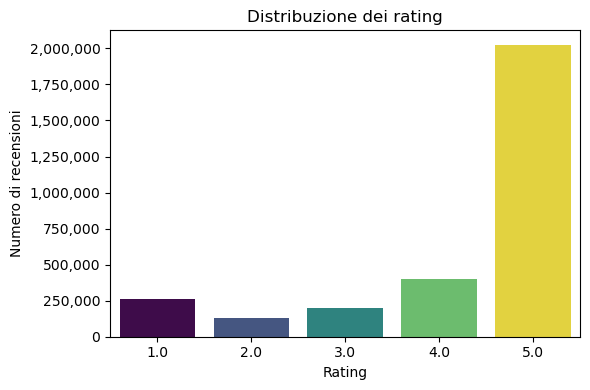

In [19]:
# distribuzione dei rating
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='rating', hue='rating', palette='viridis', legend=False)

plt.title('Distribuzione dei rating')
plt.xlabel('Rating')
plt.ylabel('Numero di recensioni')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x):,}'))

plt.tight_layout()
plt.show()

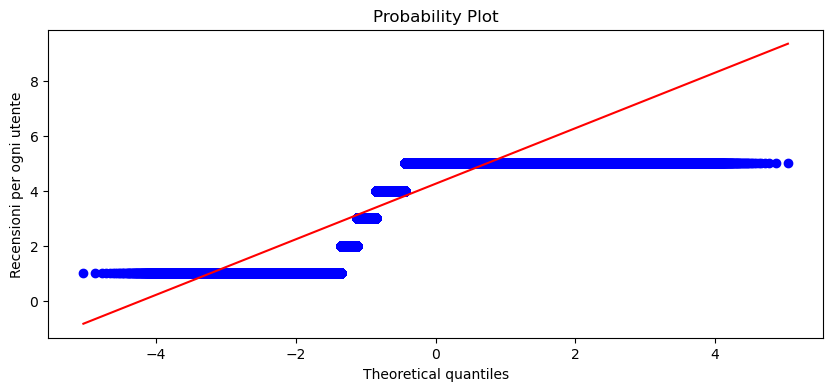

In [20]:
plt.figure(figsize=(10,4))
stats.probplot(df.rating, dist='norm', plot=plt)
plt.ylabel('Recensioni per ogni utente')
plt.show()

In [21]:
# Prima del filtraggio
n_users = df['userID'].nunique()
n_items = df['itemID'].nunique()
n_ratings = len(df)

sparsity = 1 - n_ratings / (n_users * n_items)  # calcoliamo la sparsità 
print(f"Numero di utenti: {n_users}")
print(f"Numero di item: {n_items}")
print(f"Sparsità della matrice: {sparsity:.9f} ({sparsity*100:.7f}%)")
# un valore molto vicino al 99% è interessante

Numero di utenti: 1762679
Numero di item: 213571
Sparsità della matrice: 0.999991985 (99.9991985%)


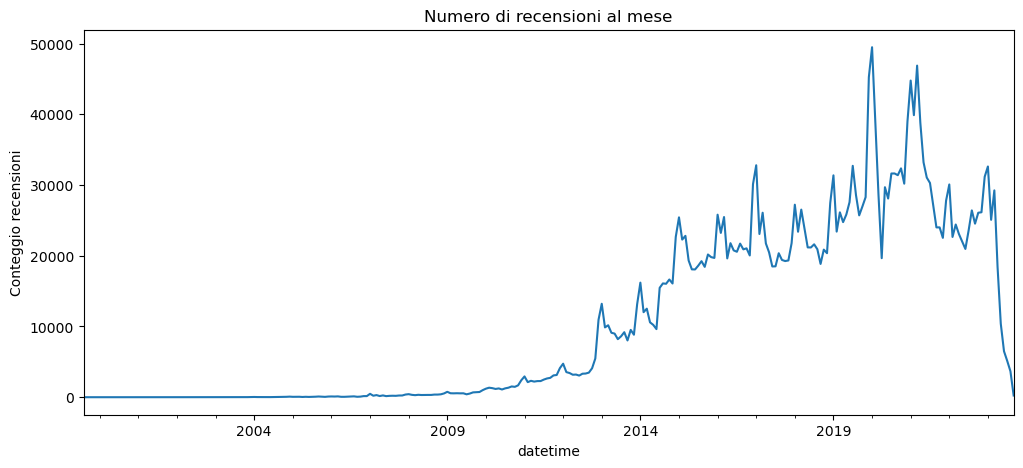

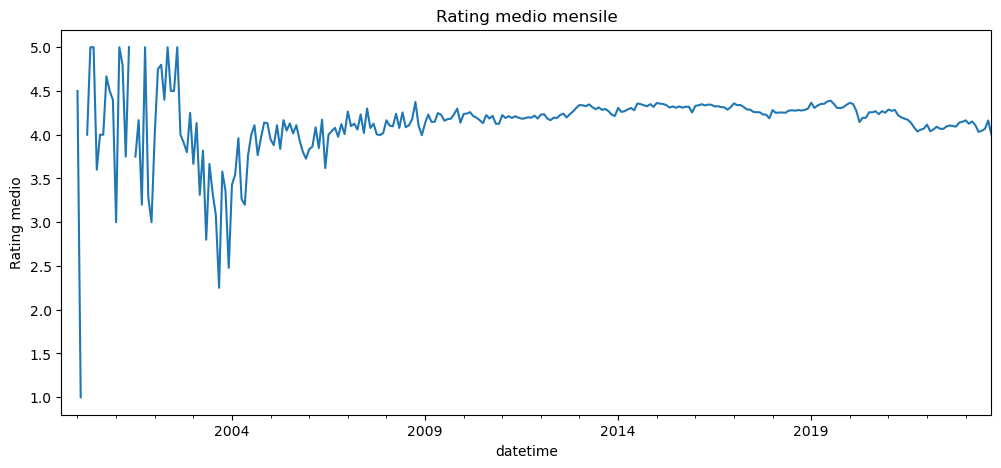

In [22]:
# Esempio di analisi temporale
# creiamo un nuovo dataframe df_time sono per questa analisi esplorativa dei dati
df_time = rev[['timestamp', 'rating']].copy()
df_time['datetime'] = pd.to_datetime(df_time['timestamp'], unit='ms')
df_time.set_index('datetime', inplace=True)

# Plot delle recensioni mensili
df_time['rating'].resample('ME').count().plot(figsize=(12, 5), title='Numero di recensioni al mese')
plt.ylabel('Conteggio recensioni')
plt.show()

# Plot del rating medio mensile
df_time['rating'].resample('ME').mean().plot(figsize=(12, 5), title='Rating medio mensile')
plt.ylabel('Rating medio')
plt.show()

In [23]:
#correlazione tra rev utente, rev ricevute prodotto, media valutazoni di utente, media rating prodotto
df_corr = df.copy()
df_corr['n_review_user'] = df_corr.groupby('userID')['rating'].transform('count')
df_corr['n_review_item'] = df_corr.groupby('itemID')['rating'].transform('count')
df_corr['mean_user_rating'] = df_corr.groupby('userID')['rating'].transform('mean')
df_corr['mean_item_rating'] = df_corr.groupby('itemID')['rating'].transform('mean')
df_corr.head()

,userID,itemID,rating,n_review_user,n_review_item,mean_user_rating,mean_item_rating
0,AGKASBHYZPGTEPO6LWZPVJWB2BVA,B003LPTAYI,5.0,1,4749,5.0,4.180248
1,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B06XP6TDVY,3.0,2,13,3.5,4.230769
2,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,B0040FJ27S,4.0,2,1355,3.5,4.261993
3,AEM663T6XHZFWLODF4US2RCOCUSA,B00WJ3HL5I,3.0,1,1788,3.0,4.013423
4,AFJTRBXMURLHS5EGNXLUHDHIZRFQ,B07T9NM5QR,5.0,1,222,5.0,4.572072


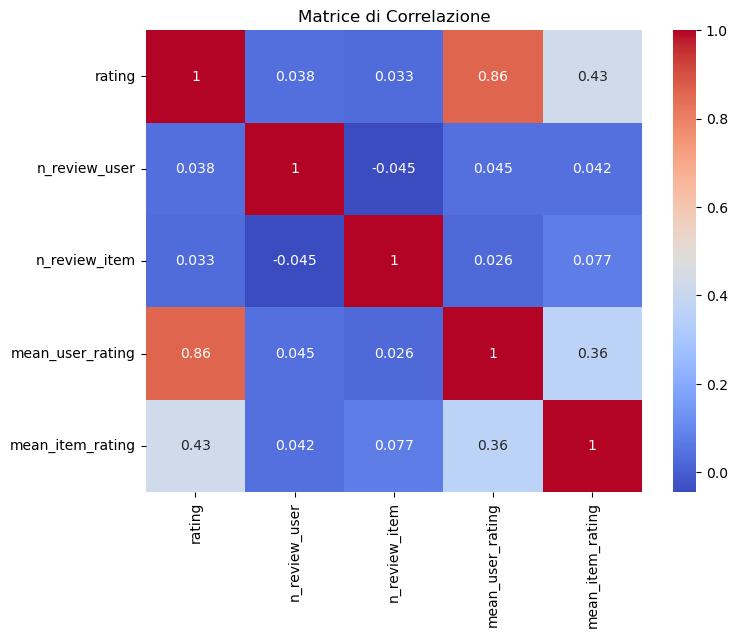

In [24]:
#grafico
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr[['rating', 'n_review_user', 'n_review_item', 'mean_user_rating', 'mean_item_rating']].corr(), annot=True, cmap='coolwarm')
plt.title("Matrice di Correlazione")
plt.show()

In [48]:
print("--- Analisi dettagliata degli item più popolari ---")


# Conta le recensioni per ogni item e filtra quelli con più di 15 recensioni
item_review_counts = df['itemID'].value_counts()
popular_items_series = item_review_counts[item_review_counts > 15]

print(f"\nNumero di item recensiti da più di 15 utenti: {len(popular_items_series)}\n")

# Prepara il DataFrame con i conteggi
popular_items_df = popular_items_series.reset_index()
popular_items_df.columns = ['itemID', 'review_count']

item_metadata_subset = item[['itemID', 'title', 'price', 'average_rating']]

# Unisci i dati
detailed_popular_items = pd.merge(popular_items_df, item_metadata_subset, on='itemID', how='left')







# Visualizza i risultati
print("I 5 item più popolari (con >15 recensioni) con titolo e descrizione:")
pd.set_option('display.max_colwidth', None)
display(detailed_popular_items.head())
pd.reset_option('display.max_colwidth')

--- Analisi dettagliata degli item più popolari ---

Numero di item recensiti da più di 15 utenti: 28813

I 5 item più popolari (con >15 recensioni) con titolo e descrizione:


,itemID,review_count,title,price,average_rating
0,B09857JRP2,9334,"GLS Audio Instrument Cable - Amp Cord for Bass & Electric Guitar - Straight to Right Angle 1/4 Inch Instrument Cable - Black/Grey Braided Tweed, 10ft",14.3,4.8
1,B09W4F2X6S,7380,"BONAOK Wireless Bluetooth Karaoke Microphone, 3-in-1 Portable Handheld Mic Speaker Machine for All Smartphones, Gifts to Girls Boys Kids Adults All Age Q37(Black Gold)",29.99,4.4
2,B0C6H9T5T6,7285,"Blue Yeti USB Microphone for PC, Mac, Gaming, Recording, Streaming, Podcasting, Studio and Computer Condenser Mic with Blue VO!CE effects, 4 Pickup Patterns, Plug and Play – Blackout",129.99,4.7
3,B0BCK6L7S5,6583,"Donner Guitar Delay Pedal, Yellow Fall Analog Delay Guitar Effect Pedal Vintage Delay True Bypass",39.99,4.4
4,B00DY1F2CS,5047,"Neewer Microphone Arm Stand, Suspension Boom Scissor Mic Arm Stand with 3/8” to 5/8” Screw and Cable Ties Compatible with Blue Yeti, Snowball, Yeti X, Quadcast and Other Mics, Max Load 1.5kg",16.99,4.3


In [49]:
# --- Analisi dettagliata degli utenti più attivi ---

print("--- Analisi dettagliata degli utenti più attivi ---")

# Conta le recensioni per ogni utente e filtra quelli con più di 30 recensioni
user_review_counts = df['userID'].value_counts()
active_users_series = user_review_counts[user_review_counts > 50]

print(f"\nNumero di utenti che hanno recensito più di 50 item: {len(active_users_series)}\n")

# Ottieni gli ID degli utenti attivi
active_user_ids = active_users_series.index

# Filtra le recensioni solo per gli utenti attivi
# (se 'active_user_ids' è vuoto, il risultato sarà un DataFrame vuoto)
active_users_data = rev[rev['user_id'].isin(active_user_ids)].rename(columns={'user_id': 'userID'})

# Calcola le statistiche aggregate per utente
user_stats = active_users_data.groupby('userID').agg(
    review_count=('rating', 'size'),
    avg_rating=('rating', 'mean'),
    verified_purchases=('verified_purchase', lambda x: x.sum())
).sort_values('review_count', ascending=False)



user_stats['avg_rating'] = user_stats['avg_rating'].round(2)

# Visualizza le statistiche. Se non ci sono utenti, verrà mostrata una tabella vuota.
print("Statistiche per i 5 utenti più attivi (con >50 recensioni):")
display(user_stats.head())

--- Analisi dettagliata degli utenti più attivi ---

Numero di utenti che hanno recensito più di 50 item: 513

Statistiche per i 5 utenti più attivi (con >50 recensioni):


,review_count,avg_rating,verified_purchases
userID,,,
AG3S4FROO422V5KP7DJCBXVUQLJQ,497,4.80,200
AEYOYD3W6NQ6DMG3F2L5E2JNAQPA,302,4.75,51
AF7CC34DK36SQJS7WXI44DREGWJA,292,4.53,286
AH4GZFH3BWFUJTLJ7P4QEFSWGZYA,257,4.35,237
AHGDGGMCSMMALHTX6WGLJFFUVJXA,240,4.47,192


## Filtro del dataframe, 2. KNN

In [26]:
# 1. Conta quante recensioni ha fatto ogni utente
user_review_counts = df['userID'].value_counts()



users_at_least_5 = user_review_counts[user_review_counts >= 30].index



# 4. Filtra il DataFrame per tenere solo le recensioni di questi utenti
df_filtered = df[df['userID'].isin(users_at_least_5)]
# 5. Conta quante recensioni ha ricevuto ogni item
item_review_counts = df_filtered['itemID'].value_counts()




items_at_least_15 = item_review_counts[item_review_counts >= 10].index




df_filtered = df_filtered[df_filtered['itemID'].isin(items_at_least_15)]

In [27]:
df_filtered['userID'].nunique()

2077

In [28]:
df_filtered['itemID'].nunique()

1402

In [29]:
df_filtered.describe().round()

,rating
count,29300.0
mean,4.0
std,1.0
min,1.0
25%,4.0
50%,5.0
75%,5.0
max,5.0


In [30]:
#matrice surprise
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df_filtered[['userID', 'itemID', 'rating']], reader)

In [31]:

# Griglia di parametri da testare:
param_grid = {
    'k': [10, 20, 30],               # più la griglia è fitta, più precisa sarà la mia predizione, però il tempo di esecuzione ne risente
    'sim_options': {
        'name': ['cosine', 'pearson', 'msd'],    # metriche di similarità che testiamo
        'user_based': [True, False]              #user/item based
    }
}
# Utilizziamo GridSearchCV per testare tutte le combinazioni
gs = model_selection.GridSearchCV(
    KNNBasic,                         # è l'algoritmo che la traccia ha detto di usare
    param_grid,                       # parametri da testare (definiti là sopra)
    measures=['rmse', 'mse'],         # usiamo RMSE e MSE come metriche di valutazione per la nostra predizione
    cv=5,
    n_jobs=-1                         # n_jobs=-1 usa tutti i core della CPU per velocizzare il processo.
)
# Avvio della ricerca
gs.fit(data)

In [32]:
#stampo configiazione ottimale
print("--- Configurazione Ottimale ---")
print(f"Miglior RMSE: {gs.best_score['rmse']:.4f}")
print(f"Miglior MSE: {gs.best_score['mse']:.4f}")

#prendo i parametri migliori
best_params = gs.best_params['rmse']
best_k = best_params['k']
best_sim_name = best_params['sim_options']['name']
best_approach = 'user-based' if best_params['sim_options']['user_based'] else 'item-based'  


print(f"\nNumero di vicini (k): {best_k}")
print(f"Metrica di similarità: {best_sim_name}")
print(f"Approccio: {best_approach}")  

#migliore combinazione di parametri ottenuta con gridSearchCv
print(f"\nBest Configuration = {gs.best_params["rmse"]}")

--- Configurazione Ottimale ---
Miglior RMSE: 1.0101
Miglior MSE: 1.0206

Numero di vicini (k): 10
Metrica di similarità: pearson
Approccio: item-based

Best Configuration = {'k': 10, 'sim_options': {'name': 'pearson', 'user_based': False}}


In [33]:
# creiamo un trainset che contiene tutte le valutazioni presenti nel dataset_surprise.
trainset = data.build_full_trainset()

# Estraiamo l'intero dizionario sim_options che contiene già sia il nome della metrica sia il valore booleano per user_based.
best_sim_options = best_params['sim_options']
print(f"Questi sono i parametri migliori: {best_sim_options}")

# Questo inizializza l'algoritmo KNN con gli iperparametri che sono stati identificati come i migliori nella ricerca su griglia precedente
algo = KNNBasic(k=best_k, sim_options=best_sim_options)

# Alleniamo il nostro algoritmo
algo.fit(trainset)

print("\n--- Stima della performance del modello ottimale ---")
cross_validate(algo, data, cv=5, measures=['MSE', 'RMSE'], verbose=True)

Questi sono i parametri migliori: {'name': 'pearson', 'user_based': False}
Computing the pearson similarity matrix...
Done computing similarity matrix.

--- Stima della performance del modello ottimale ---
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Evaluating MSE, RMSE of algorithm KNNBasic on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
MSE (testset)     0.9525  1.0223  1.0164  1.0177  1.0570  1.0132  0.0338  
RMSE (testset)    0.9760  1.0111  1.0081  1.0088  1.0281  1.0064  0.0169  
Fit time          0.11    0.11    0.11    0.12    0.12    0.11    0.00    
Test time         0.08    0.08    0.08    0.08    

{'test_mse': array([0.95248675, 1.02232522, 1.01635892, 1.01768977, 1.05695149]),
 'test_rmse': array([0.97595428, 1.011101  , 1.00814628, 1.00880611, 1.02808146]),
 'fit_time': (0.10951805114746094,
  0.11252021789550781,
  0.10904335975646973,
  0.12152981758117676,
  0.11551117897033691),
 'test_time': (0.07951688766479492,
  0.07651519775390625,
  0.07928586006164551,
  0.07851767539978027,
  0.08303499221801758)}

## 3. Filling della matrice di rating con la configurazione ottimale

In [34]:
# Creiamo la matrice di rating sparsa
# Le celle non valutate saranno NaN
print("Creazione della matrice sparsa...")
sparse_rating_matrix = df_filtered.pivot_table(index='userID', columns='itemID', values='rating')

# Creiamo una copia per non modificare l'originale
filled_rating_matrix = sparse_rating_matrix.copy()

print("Matrice sparsa creata. Esempio delle prime 5 righe/colonne:")
filled_rating_matrix

Creazione della matrice sparsa...
Matrice sparsa creata. Esempio delle prime 5 righe/colonne:


itemID,1423414357,B00005ML71,B0002CZTIO,B0002CZVWS,B0002D01K4,B0002D01KO,B0002D0CCQ,B0002D0CEO,B0002D0CNA,B0002D0L5E,...,B0C6J149WZ,B0C6J1X7TD,B0C6J2DPBW,B0C994NVQK,B0C9NGP88D,B0CB6YQR5W,B0CB98SMQR,B0CBK1WSMR,B0CCK4YYNM,B0CF797FLB
userID,,,,,,,,,,,,,,,,,,,,,
AE23LDQTB7L76AP6E6WPBFVYL5DA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AE23WLBRYKEC67DM43M6E2MF7GPQ,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AE23ZFVUOMPKR57BVSWXV34QLMVA,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AE27PVJOEVGOHYF5WOXQDZ5NIULA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AE2AII7ZOEPCPPFDPF33HPSNBAPQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AHZNF3H5YLL623I5C6PO3TVZFXSQ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AHZPDHP2UGRX5WIITRFMSKS2WRXA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AHZQPH7HHSWLUIQFWEQ54NNKKN6A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# Eseguiamo il filling della matrice
#Se una cella è NaN, la riempiamo con la predizione.
print("\nInizio del processo di filling della matrice...")
for user_id in tqdm(filled_rating_matrix.index, desc="Utenti"):
    for item_id in filled_rating_matrix.columns:
        # Controlliamo se il rating è mancante
        if np.isnan(filled_rating_matrix.loc[user_id, item_id]):
            # Se è mancante, usiamo il nostro algoritmo addestrato per predirlo
            # poi approssimo tutto prendendo solo le ultime 2 cifre decimali, altrimenti vengono numeri troppo lunghi
            predicted_rating = round(algo.predict(uid=user_id, iid=item_id).est, 2)
            filled_rating_matrix.loc[user_id, item_id] = predicted_rating
print("Processo di filling completato.")
filled_rating_matrix


Inizio del processo di filling della matrice...


Utenti: 100%|██████████████████████████████████████████████████████████████████████| 2077/2077 [06:02<00:00,  5.73it/s]

Processo di filling completato.


itemID,1423414357,B00005ML71,B0002CZTIO,B0002CZVWS,B0002D01K4,B0002D01KO,B0002D0CCQ,B0002D0CEO,B0002D0CNA,B0002D0L5E,...,B0C6J149WZ,B0C6J1X7TD,B0C6J2DPBW,B0C994NVQK,B0C9NGP88D,B0CB6YQR5W,B0CB98SMQR,B0CBK1WSMR,B0CCK4YYNM,B0CF797FLB
userID,,,,,,,,,,,,,,,,,,,,,
AE23LDQTB7L76AP6E6WPBFVYL5DA,5.00,4.49,4.49,4.49,4.49,4.49,4.49,5.00,4.49,4.49,...,4.49,5.00,4.49,4.49,4.49,4.49,4.49,4.49,4.49,4.49
AE23WLBRYKEC67DM43M6E2MF7GPQ,5.00,4.49,4.49,4.49,4.49,4.49,4.49,4.49,4.49,4.49,...,4.49,4.49,4.49,4.49,4.49,4.49,4.49,4.49,4.49,4.49
AE23ZFVUOMPKR57BVSWXV34QLMVA,4.49,4.49,4.49,5.00,4.49,4.49,5.00,5.00,3.00,4.49,...,4.49,3.67,4.49,4.49,4.49,4.49,4.49,3.00,4.49,4.49
AE27PVJOEVGOHYF5WOXQDZ5NIULA,4.49,4.49,4.49,4.49,4.49,5.00,4.49,4.49,4.49,5.00,...,4.49,4.49,4.49,4.49,5.00,4.49,4.49,4.49,4.49,4.49
AE2AII7ZOEPCPPFDPF33HPSNBAPQ,4.49,4.49,4.49,4.49,4.49,4.49,4.49,4.49,4.49,4.49,...,4.49,4.00,4.49,4.49,4.49,4.49,4.49,4.49,4.49,4.49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AHZNF3H5YLL623I5C6PO3TVZFXSQ,5.00,5.00,4.49,4.49,4.49,4.49,4.00,5.00,1.00,4.49,...,4.49,4.00,5.00,4.49,5.00,4.49,4.49,5.00,4.14,4.49
AHZPDHP2UGRX5WIITRFMSKS2WRXA,4.49,4.49,4.49,4.49,4.49,4.49,4.49,4.49,4.49,4.49,...,4.49,4.49,4.49,4.49,4.49,4.49,4.49,4.49,4.49,4.49
AHZQPH7HHSWLUIQFWEQ54NNKKN6A,5.00,4.49,5.00,4.49,4.49,4.49,1.00,1.00,4.49,5.00,...,4.49,5.00,4.49,4.49,4.49,4.49,4.49,4.49,5.00,4.49


## 4. algoritmo di clustering K-MEANS con cosine similarity.


--- Segmentazione degli Utenti con K-Means e Cosine Similarity ---

Normalizzazione della matrice riempita con KNN...

Calcolo di WCSS e Silhouette Score per trovare il k ottimale...


C:\Users\lucab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Per k = 2, WCSS = 8.63, Silhouette Score = 0.6203


C:\Users\lucab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Per k = 3, WCSS = 8.12, Silhouette Score = 0.5812


...

Per k = 8, WCSS = 6.91, Silhouette Score = 0.0375


C:\Users\lucab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Per k = 9, WCSS = 6.88, Silhouette Score = 0.3426


C:\Users\lucab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


Per k = 10, WCSS = 6.59, Silhouette Score = 0.1638


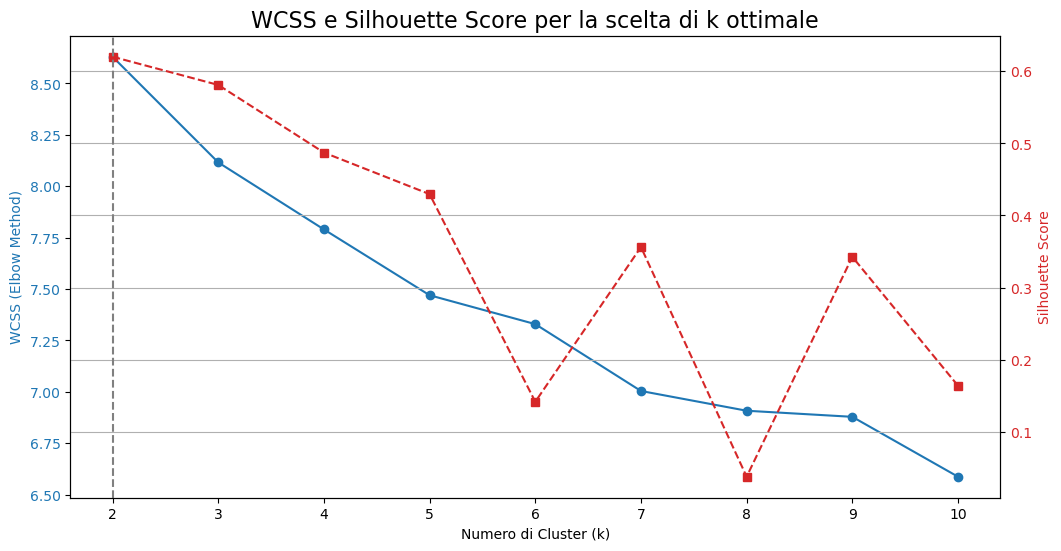


Il k ottimale scelto è: 2

Esecuzione del clustering finale con k=2...


C:\Users\lucab\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(



--- Analisi dei Cluster Generati ---
Numero di utenti per cluster:
cluster
0    2036
1      41
Name: count, dtype: int64
----------------------------------------
Statistiche dei rating per cluster:
           count      mean       std  min  25%  50%  75%  max
cluster                                                      
0        28512.0  4.506769  0.963300  1.0  4.0  5.0  5.0  5.0
1          788.0  3.765228  1.365563  1.0  3.0  4.0  5.0  5.0

Creazione della visualizzazione dei cluster con PCA...


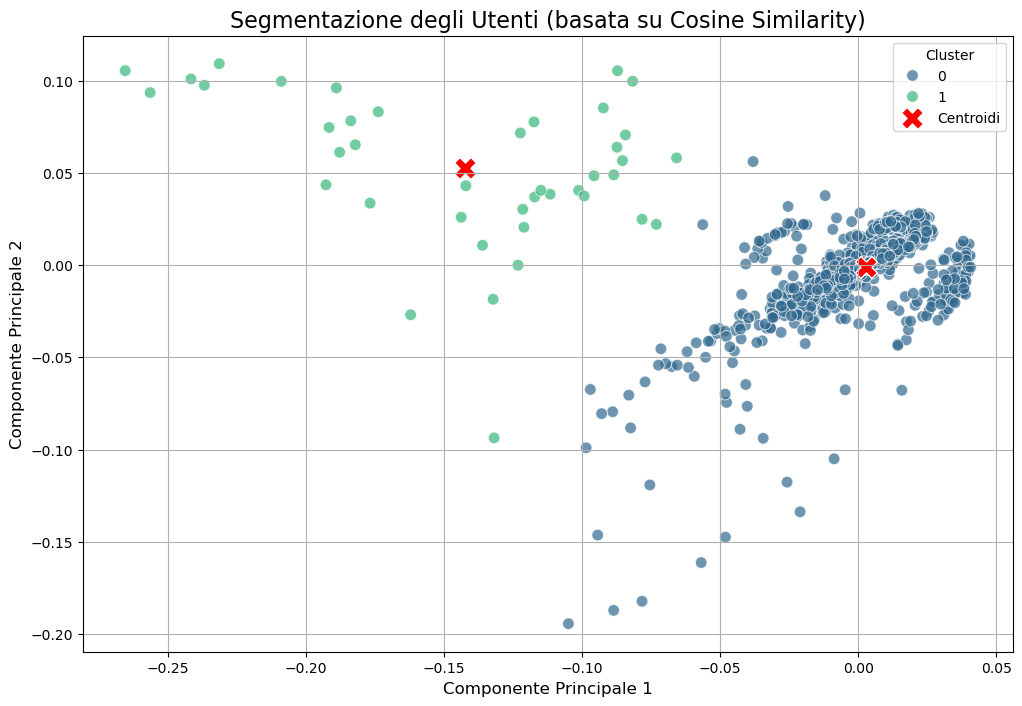

In [57]:
print("--- Segmentazione degli Utenti con K-Means e Cosine Similarity ---")

# Per usare K-Means con la cosine similarity, prima normalizziamo i dati con L2 che scala ogni vettore 
# in modo che la sua lunghezza sia pari a 1.
print("\nNormalizzazione della matrice riempita con KNN...")
matrix_for_clustering = normalize(filled_rating_matrix, norm='l2', axis=1)  # axis=1 normalizziamo riga per riga

# Determinazione del K ottimale (Metodo del Gomito e Silhouette)
wcss = []
silhouette_scores = []
k_range = range(2, 11)  # Testiamo da 2 a 11 cluster

print("\nCalcolo di WCSS e Silhouette Score per trovare il k ottimale...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(matrix_for_clustering)
    wcss.append(kmeans.inertia_)
    labels = kmeans.labels_
    
    # La silhouette score viene calcolata con la metrica euclidea sui dati normalizzati,
    # che è il modo corretto per valutare cluster basati su cosine similarity.
    silhouette_avg = silhouette_score(matrix_for_clustering, labels, metric='euclidean')
    silhouette_scores.append(silhouette_avg)
    print(f"Per k = {k}, WCSS = {kmeans.inertia_:.2f}, Silhouette Score = {silhouette_avg:.4f}")

# Visualizzazione per la scelta di K
fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'tab:blue'
ax1.set_xlabel('Numero di Cluster (k)')
ax1.set_ylabel('WCSS (Elbow Method)', color=color)
ax1.plot(k_range, wcss, marker='o', linestyle='-', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('WCSS e Silhouette Score per la scelta di k ottimale', fontsize=16)
plt.xticks(np.arange(min(k_range), max(k_range)+1, 1))
plt.axvline(x=2, color='gray', linestyle='--')
plt.grid(True)
plt.show()

# Scegliamo k=2 basandoci sulla combinazione dei due grafici
optimal_k = 2
print(f"\nIl k ottimale scelto è: {optimal_k}")

# Clustering Finale e Analisi
print(f"\nEsecuzione del clustering finale con k={optimal_k}...")
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
kmeans.fit(matrix_for_clustering)

user_clusters = pd.DataFrame(kmeans.labels_, index=filled_rating_matrix.index, columns=['cluster'])
df_clustered = df_filtered.merge(user_clusters, on='userID')

print("\n--- Analisi dei Cluster Generati ---")
print("Numero di utenti per cluster:")
print(user_clusters['cluster'].value_counts())
print("-" * 40)
print("Statistiche dei rating per cluster:")
print(df_clustered.groupby('cluster')['rating'].describe())

print("\nCreazione della visualizzazione dei cluster con PCA...")
pca = PCA(n_components=2)
principal_components = pca.fit_transform(matrix_for_clustering)
pca_df = pd.DataFrame(data=principal_components, columns=['Componente Principale 1', 'Componente Principale 2'])
pca_df.index = filled_rating_matrix.index
pca_df = pca_df.join(user_clusters)

centroids = kmeans.cluster_centers_
centroid_pcs = pca.transform(centroids)

plt.figure(figsize=(12, 8))
sns.scatterplot(x='Componente Principale 1', y='Componente Principale 2', hue='cluster',
                data=pca_df, palette='viridis', legend='full', s=70, alpha=0.7)
plt.scatter(centroid_pcs[:, 0], centroid_pcs[:, 1], s=250, c='red', marker='X',
            label='Centroidi', edgecolor='white')
plt.title('Segmentazione degli Utenti (basata su Cosine Similarity)', fontsize=16)
plt.xlabel('Componente Principale 1', fontsize=12)
plt.ylabel('Componente Principale 2', fontsize=12)
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# 5. Creazione funzione top 10 per utente

In [37]:
# funzione per prendere i top 10 raccomandati rispetto all'utente
def get_top_n_recommendations(user_id, sparse_matrix, filled_matrix, item_metadata, n=10):
    #Vedo cosa l'utente ha gia valutato
    user_ratings = sparse_matrix.loc[user_id]
    #Identifico gli item che l'utente NON ha ancora valutato
    unrated_items = user_ratings[user_ratings.isna()].index
    #i rating predetti per gli item non valutati dalla matrice riempita
    predicted_ratings = filled_matrix.loc[user_id, unrated_items]
    # ordina gli item in base al rating predetto, in ordine decrescente
    recommendations = predicted_ratings.sort_values(ascending=False).head(n)

    #Formatta l'output in un DataFrame e aggiungi i titoli dei prodotti
    rec_df = recommendations.to_frame('predicted_rating').reset_index()
    rec_df = rec_df.merge(item_metadata, on='itemID', how='left')

    return rec_df

In [38]:
#ESEMPIO , uso il primo utente della matrice
sample_user_id = filled_rating_matrix.index[0]
item_info = item[['itemID', 'title']] 

knn_recommendations = get_top_n_recommendations(
    user_id=sample_user_id,
    sparse_matrix=sparse_rating_matrix,
    filled_matrix=filled_rating_matrix, # Usiamo la matrice riempita con KNN
    item_metadata=item_info,
    n=10
)

print(f"--- Top 10 Raccomandazioni (KNN) per l'utente: {sample_user_id} ---")
knn_recommendations

--- Top 10 Raccomandazioni (KNN) per l'utente: AE23LDQTB7L76AP6E6WPBFVYL5DA ---


,itemID,predicted_rating,title
0,1423414357,5.0,"Guitar Aerobics: A 52-Week, One-lick-per-day W..."
1,B01DNC1EEW,5.0,"Ernie Ball Glass Slide, Medium (P04228)"
2,B0B16WH36J,5.0,String Swing CC01K-BW Guitar Hanger and Guitar...
3,B0B179FY4C,5.0,"EBXYA Guitar Tuner Pedal, Mini Distortion Guit..."
4,B0B1LK9SXB,5.0,UGY Capo Guitar Capo for Acoustic and Electric...
5,B01DE4DVO0,5.0,"Hosa GTR-518 Straight Tweed Guitar Cable, 18 Feet"
6,B01DE4DTAG,5.0,Hosa GTR-220R Guitar Cable Straight to Right A...
7,B0B1SF7C4M,5.0,Wayfinder Supply Co. Lightweight Electric Guit...
8,B01DE4D4LU,5.0,Hosa CPE-118 Right Angle to Right Angle Guitar...
9,B01DBS2U9G,5.0,Fishman Neo-D Dark Brown Single Coil Soundhole...


In [39]:
sample_user_id = filled_rating_matrix.index[2000]
knn_recommendations = get_top_n_recommendations(user_id=sample_user_id, sparse_matrix=sparse_rating_matrix, filled_matrix=filled_rating_matrix, item_metadata=item_info, n=10)
print(f"--- Top 10 Raccomandazioni (KNN) per l'utente: {sample_user_id} ---")
knn_recommendations

--- Top 10 Raccomandazioni (KNN) per l'utente: AHVJZIPGKB6EENMRVZGXZRWEQWTA ---


,itemID,predicted_rating,title
0,B018FCZKR2,5.00,Amazon Basics Adjustable Guitar Folding A-Fram...
1,B07L5B64RG,5.00,Getaria Upgrade 2.4GHZ Wireless Guitar System ...
2,B0BCK6L7S5,5.00,"Donner Guitar Delay Pedal, Yellow Fall Analog ..."
3,B08R5GM6YB,5.00,"D'Addario Pro-Winder - Guitar String Winder, G..."
4,B08Y997LFQ,5.00,Gearlux Bass Guitar Hard Case - Rectangular
5,B07VPLFNYM,5.00,Best Choice Products 22-Fret Full Size Acousti...
6,B0B95V41NR,5.00,D'Addario Guitar Cable - Guitar Patch Cable - ...
7,B0BPJ4Q6FJ,4.78,D'Addario Guitar Strings - XL Nickel Electric ...
8,B099NFZP4S,4.49,Donner Guitar Patch Cables Right Angle 12 Inch...
9,B09BS25NJM,4.49,D'Addario Auto Lock Guitar Strap - Acoustic & ...


# 6. Filling della matrice di rating attraverso Matrix Factorization 

In [40]:
# Definiamo la griglia di parametri da testare per SVD
param_grid_svd = {
    'n_epochs': [20, 30],  #numero di epoche
    'lr_all': [0.005, 0.01], #learning rate
    'reg_all': [0.02, 0.1] #regolarizzazione
}

# Eseguiamo la Grid Search
gs_svd = GridSearchCV(SVD, param_grid_svd, measures=['rmse', 'mse'], cv=5, n_jobs=-1)
gs_svd.fit(data) # 'data' è il dataset surprise creato in precedenza







print("--- Migliore Configurazione per SVD ---")
print(f"Miglior RMSE (SVD): {gs_svd.best_score['rmse']:.4f}")
print(f"Migliore Configurazione: {gs_svd.best_params['rmse']}")

--- Migliore Configurazione per SVD ---
Miglior RMSE (SVD): 0.9015
Migliore Configurazione: {'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.1}


In [41]:
# Istanziamo e addestriamo il modello SVD con i parametri migliori
best_params_svd = gs_svd.best_params['rmse']
svd_algo = SVD(**best_params_svd)
trainset = data.build_full_trainset()
svd_algo.fit(trainset)

# Creiamo una nuova matrice da riempire con le predizioni di SVD
svd_filled_matrix = sparse_rating_matrix.copy()

print("\nInizio del processo di filling della matrice con SVD...")

for user_id in tqdm(svd_filled_matrix.index, desc="Utenti SVD"):
    for item_id in svd_filled_matrix.columns:
        if pd.isna(svd_filled_matrix.loc[user_id, item_id]):
            predicted_rating = svd_algo.predict(uid=user_id, iid=item_id).est
            svd_filled_matrix.loc[user_id, item_id] = predicted_rating

print("Processo di filling con SVD completato.")
svd_filled_matrix.head()


Inizio del processo di filling della matrice con SVD...


Utenti SVD: 100%|██████████████████████████████████████████████████████████████████| 2077/2077 [05:24<00:00,  6.40it/s]

Processo di filling con SVD completato.


itemID,1423414357,B00005ML71,B0002CZTIO,B0002CZVWS,B0002D01K4,B0002D01KO,B0002D0CCQ,B0002D0CEO,B0002D0CNA,B0002D0L5E,...,B0C6J149WZ,B0C6J1X7TD,B0C6J2DPBW,B0C994NVQK,B0C9NGP88D,B0CB6YQR5W,B0CB98SMQR,B0CBK1WSMR,B0CCK4YYNM,B0CF797FLB
userID,,,,,,,,,,,,,,,,,,,,,
AE23LDQTB7L76AP6E6WPBFVYL5DA,4.756526,5.000000,4.227411,4.942841,4.947364,4.607430,5.000000,4.890404,4.910216,4.962925,...,4.974596,4.834820,4.890518,4.746713,4.447788,4.901388,5.000000,4.466165,4.401119,5.000000
AE23WLBRYKEC67DM43M6E2MF7GPQ,5.000000,4.151897,3.551466,3.953318,4.155999,3.709143,4.341298,4.120102,4.123248,4.109862,...,4.340038,3.914374,4.284382,3.946477,3.702396,4.360337,4.409922,3.867809,3.619861,4.406312
AE23ZFVUOMPKR57BVSWXV34QLMVA,4.656237,4.725314,4.101645,5.000000,4.598257,4.364615,4.855782,4.578692,4.626850,4.737867,...,4.693814,4.549845,4.796187,4.440850,4.312563,4.716377,4.968983,4.318023,4.282698,4.856258
AE27PVJOEVGOHYF5WOXQDZ5NIULA,4.289055,4.554498,3.777042,4.478656,4.393485,4.007686,4.695885,4.332385,4.432855,4.327002,...,4.672979,4.225762,4.775480,4.161224,4.109191,4.638983,4.834458,4.100133,3.693877,4.586736
AE2AII7ZOEPCPPFDPF33HPSNBAPQ,3.743223,3.948626,3.339203,3.881335,3.815222,3.613320,4.198796,3.797066,3.949626,3.947035,...,3.921689,4.031233,4.000834,3.824419,3.499034,3.908109,4.185263,3.568804,3.580552,4.027655


In [42]:
# Lista dei modelli da confrontare
models = [
    algo,      # algoritmo KNN ottimizzato
    svd_algo   # L'SVD ottimizzato appena creato
]

benchmark = []

# Eseguiamo la cross-validation per ogni modello ( diviso in 5 parti)
for model in models:
    results = cross_validate(model, data, measures=['MSE', 'RMSE'], cv=5, verbose=False)

    # Calcoliamo la media dei risultati
    tmp = pd.DataFrame.from_dict(results).mean(axis=0)
    tmp = pd.concat([tmp, pd.Series([str(model).split(' ')[0].split('.')[-1]], index=['Algorithm'])])
    benchmark.append(tmp)

# Creiamo un DataFrame con i risultati e ordiniamoli per RMSE
results_df = pd.DataFrame(benchmark).set_index('Algorithm').sort_values('test_rmse')

print("\n--- Confronto delle Performance dei Modelli (5-Fold Cross-Validation) ---")
print(results_df)

Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.
Computing the pearson similarity matrix...
Done computing similarity matrix.

--- Confronto delle Performance dei Modelli (5-Fold Cross-Validation) ---
           test_mse  test_rmse  fit_time  test_time
Algorithm                                          
SVD        0.817492   0.904082  0.164053   0.041702
KNNBasic   1.021780   1.010385  0.107958   0.077422


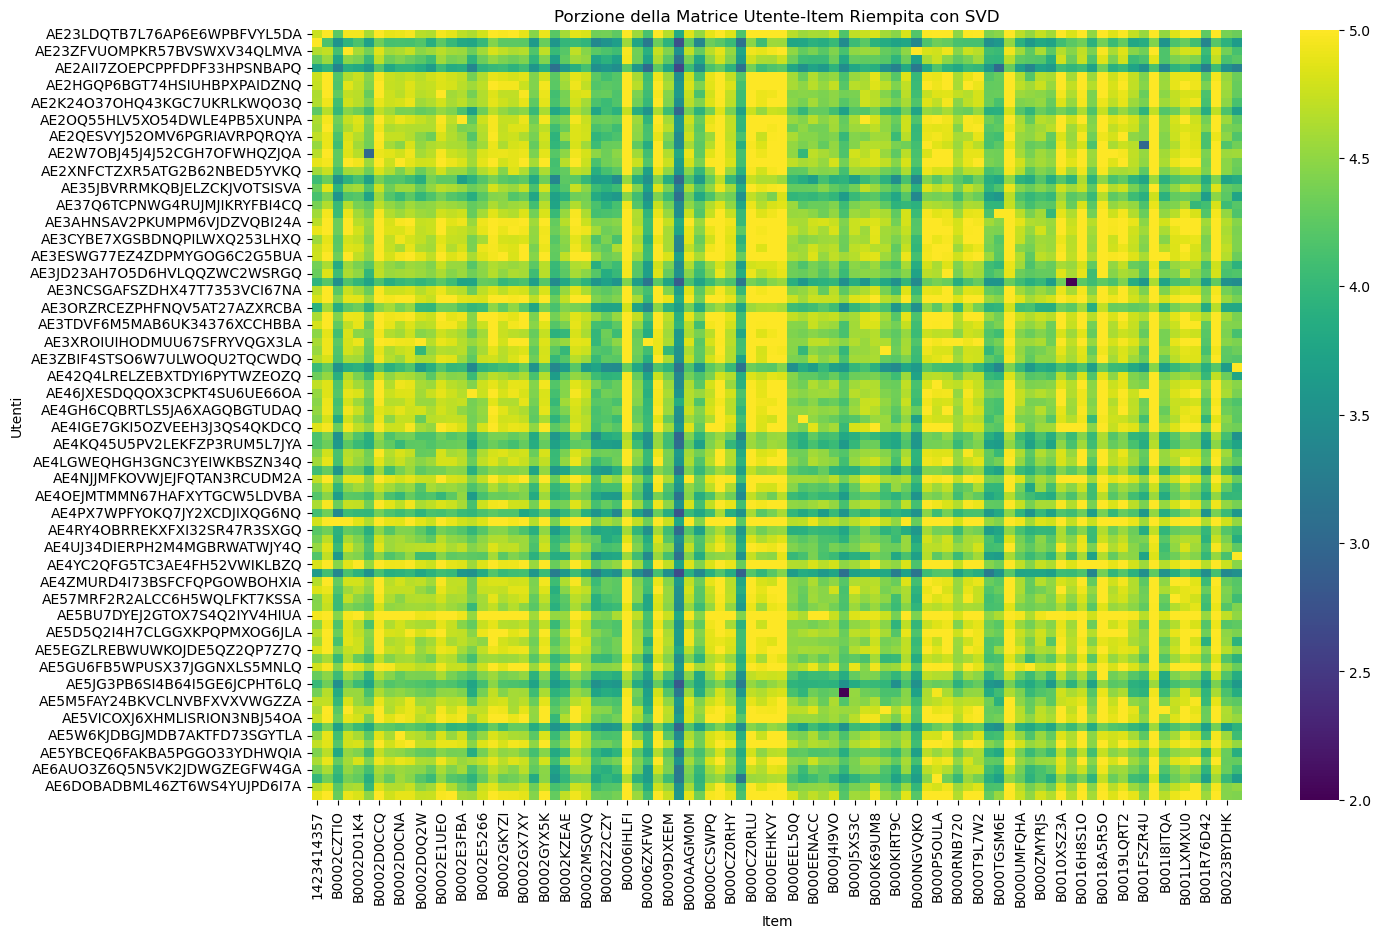

In [43]:
# Codice trovato su internet, molto bello
# Selezioniamo solo una porzione per la visualizzazione (es. 20 utenti x 30 item)
subset_matrix = svd_filled_matrix.iloc[:90, :90]

plt.figure(figsize=(15, 10))
sns.heatmap(subset_matrix, cmap="viridis", annot=False) # Annot=False perché i numeri si sovrapporrebbero
plt.title("Porzione della Matrice Utente-Item Riempita con SVD")
plt.xlabel("Item")
plt.ylabel("Utenti")
plt.show()

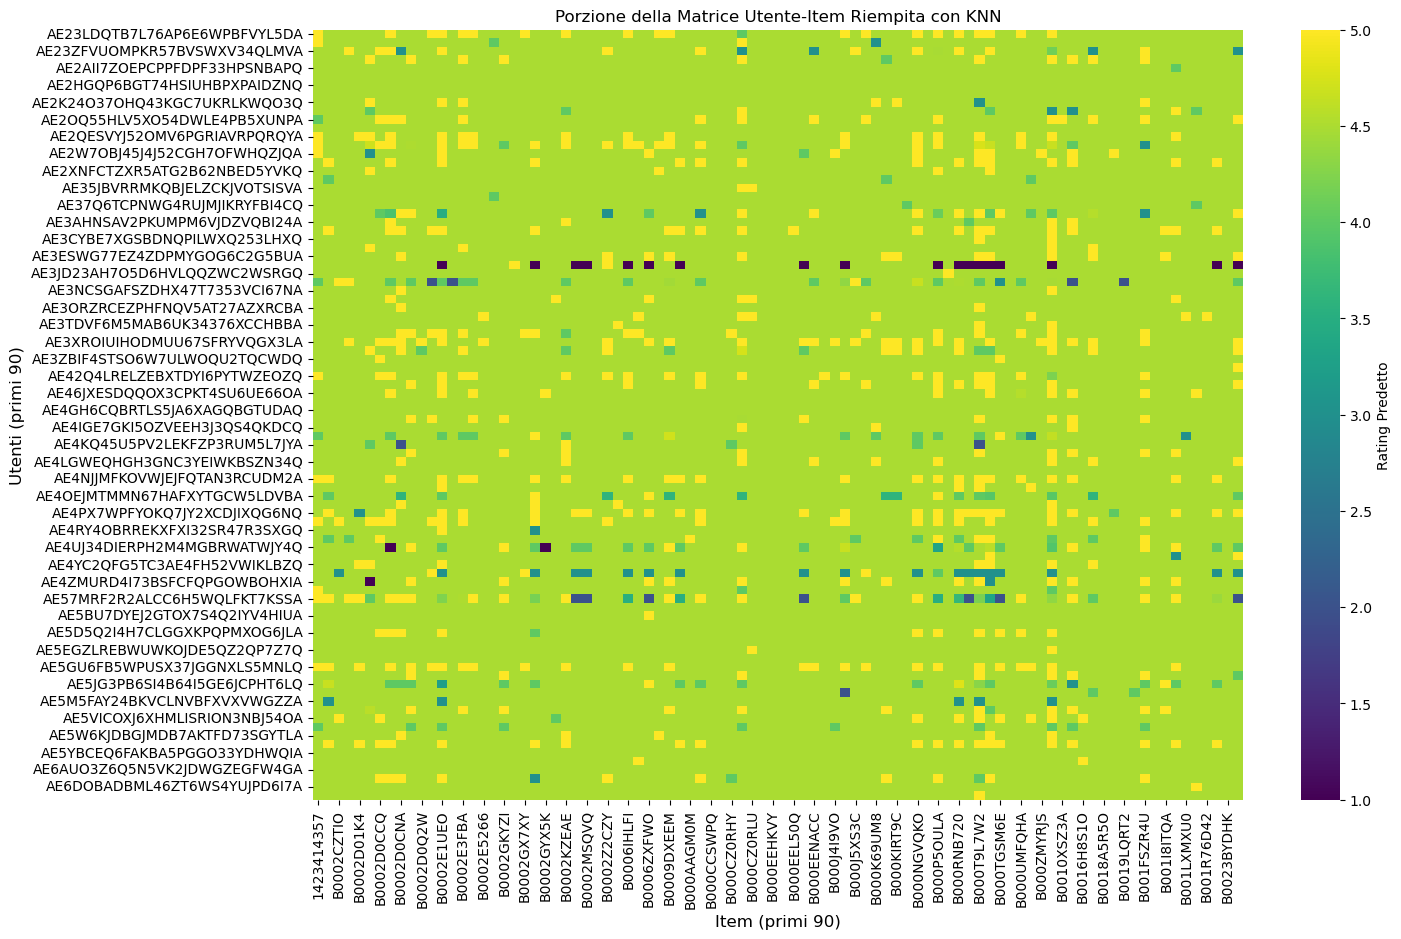

In [58]:

subset_matrix_knn = filled_rating_matrix.iloc[:90, :90]
plt.figure(figsize=(15, 10))
sns.heatmap(subset_matrix_knn, cmap="viridis", annot=False, cbar_kws={'label': 'Rating Predetto'})
plt.title("Porzione della Matrice Utente-Item Riempita con KNN")
plt.xlabel("Item (primi 90)", fontsize=12)
plt.ylabel("Utenti (primi 90)", fontsize=12)
plt.show()

In [45]:
# Piccola analisi aggiuntiva: per ogni cluster, troviamo i 10 item con il rating predetto più alto
for i in range(optimal_k):
    print(f"\n\n--- Profilo Cluster {i} ---")
    # Seleziona gli utenti del cluster
    user_ids_in_cluster = user_clusters[user_clusters['cluster'] == i].index

    # Calcola il rating medio per ogni item all'interno del cluster
    cluster_item_ratings = filled_rating_matrix.loc[user_ids_in_cluster].mean().sort_values(ascending=False).head(10)

    # Aggiungi i titoli dei prodotti
    cluster_item_ratings_df = cluster_item_ratings.to_frame('avg_rating').reset_index()
    cluster_item_ratings_df = cluster_item_ratings_df.merge(item_info, on='itemID', how='left')

    print(f"Top 10 item preferiti dal cluster {i}:")
    print(cluster_item_ratings_df[['title', 'avg_rating']])



--- Profilo Cluster 0 ---
Top 10 item preferiti dal cluster 0:
                                               title  avg_rating
0  Fender Performance Series Instrument Cables (S...    4.570653
1  Fender Deluxe Locking Staggered Guitar Tuners,...    4.562441
2  D'Addario PL019 Plain Steel Guitar Single Stri...    4.558708
3  Fender Premium Celluloid Guitar Picks 351 Shap...    4.557184
4  D'Addario Guitar Cable - Geo Tip for Secure Co...    4.554990
5  GraphTech PT606000 TUSQ XL Black Self-Lubricat...    4.554651
6  Shure A58WS-BLU Foam Windscreen for All Shure ...    4.554563
7  Fishman Neo-D Dark Brown Single Coil Soundhole...    4.554357
8  Musiclily 52.5mm Guitar Stratocaster Tremolo B...    4.552377
9                Lee Oskar Harmonica, Major Key of E    4.552230


--- Profilo Cluster 1 ---
Top 10 item preferiti dal cluster 1:
                                               title  avg_rating
0  Donner Pedalboard Pedal Tape，Guitar Pedal Boar...    4.594390
1  Elixir Strings Nickel 

In [46]:
# scegli qui utente da prevedere
user_id_esempio = filled_rating_matrix.index[300] 

# Mostriamo il profilo dell'utente  : i suoi 5 item preferiti (già recensiti)
print(f"--- Profilo dell'utente: {user_id_esempio} ---")
print("I 5 item che ha valutato con il punteggio più alto:")

# Filtriamo le recensioni originali per questo utente
user_profile = df_filtered[df_filtered['userID'] == user_id_esempio]

# Uniamo con i metadati degli item per avere i titoli
user_profile_with_titles = user_profile.merge(item_info, on='itemID', how='left')

# Ordiniamo per rating e mostriamo i migliori
display(user_profile_with_titles.sort_values(by='rating', ascending=False).head(5))




print("\n--- Appartenenza al Cluster dell'utente ---")
cluster_assegnato = user_clusters.loc[user_id_esempio, 'cluster']
print(f"L'utente {user_id_esempio} appartiene al cluster numero: {cluster_assegnato} \n")




# Raccomandazioni KNN
knn_recs = get_top_n_recommendations(user_id_esempio, sparse_rating_matrix, filled_rating_matrix, item_info, n=5)

# Raccomandazioni SVD
svd_recs = get_top_n_recommendations(user_id_esempio, sparse_rating_matrix, svd_filled_matrix, item_info, n=5)

print(f"--- Confronto Raccomandazioni per l'utente: {user_id_esempio} ---")
print("\nTop 5 Raccomandazioni (KNN - Basato sulla similarità):")
display(knn_recs)

print("\nTop 5 Raccomandazioni (SVD - Basato su fattori latenti):")
display(svd_recs)

--- Profilo dell'utente: AELHFSFNZGMUKRQ6Q2MYN367HZUA ---
I 5 item che ha valutato con il punteggio più alto:


,userID,itemID,rating,title
10,AELHFSFNZGMUKRQ6Q2MYN367HZUA,B01DPCONFM,5.0,Fender Performance Series Instrument Cables (S...
1,AELHFSFNZGMUKRQ6Q2MYN367HZUA,B0BYXQHW7Y,5.0,Rode PSA1
17,AELHFSFNZGMUKRQ6Q2MYN367HZUA,B016QUXTZU,5.0,"Enabled Dragonpad USA- 6"" Microphone Studio Po..."
16,AELHFSFNZGMUKRQ6Q2MYN367HZUA,B00H4PEMM6,5.0,"JIM DUNLOP Curved, Nickel, Guitar Capo"
15,AELHFSFNZGMUKRQ6Q2MYN367HZUA,B09G5QS1VD,5.0,Ernie Ball Beefy Slinky Cobalt Electric Guitar...



--- Appartenenza al Cluster dell'utente ---
L'utente AELHFSFNZGMUKRQ6Q2MYN367HZUA appartiene al cluster numero: 0 

--- Confronto Raccomandazioni per l'utente: AELHFSFNZGMUKRQ6Q2MYN367HZUA ---

Top 5 Raccomandazioni (KNN - Basato sulla similarità):


,itemID,predicted_rating,title
0,B0BFKQ9QXD,5.0,Ernie Ball Earthwood Medium Phosphor Bronze Ac...
1,B09QDL744G,5.0,Mighty Bright 54810 Hammerhead Music Stand Light
2,B00N5THDR6,5.0,On-Stage GS7255 Double Hang-It Guitar Stand
3,B0BM71QK8M,5.0,Monoprice 104774 50-Feet Premier Series XLR Fe...
4,B07DK59QNR,5.0,Truetone 1 Spot Adapter



Top 5 Raccomandazioni (SVD - Basato su fattori latenti):


,itemID,predicted_rating,title
0,B07M81HC4C,5.0,"Glaesel Violin Practice Mute, Black (GL3834)"
1,B07N1RPV4J,5.0,D’Addario Woodwinds Multi-Instrument Reed Vita...
2,B07JL1KFT3,5.0,Wampler Ego Compressor V2 Guitar Effects Pedal
3,B07KRZ1HH8,5.0,GETMusic 3MM Electric Guitar Bass Pickguard Sc...
4,B07KZ9VXS2,5.0,Gator Cases Microphone Hard Case with Foam Dro...
